In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from dotenv import load_dotenv
import os

In [21]:
load_dotenv()
DIST_S1_DATA_DIR = Path(os.getenv("DIST_EVENT_DATA"))
DIST_S1_DATA_DIR.name

'confirmed_products_dist-event-nov'

In [22]:
events_processed_dir = Path(f'out_{DIST_S1_DATA_DIR.name}/f1_events')
metadata_files = list(events_processed_dir.rglob('**/metrics.json'))
metadata_files

[PosixPath('out_confirmed_products_dist-event-nov/f1_events/hokkaido_landslides_2018/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/attica_fire_2024/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/chile_fire_2024/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/los_angeles_fires_2025/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/papau_new_guinea_landslide_2024/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/chilcotin_river_landslide_and_flood_2024/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/tuscany_flood_2023/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/afghanistan_flood_2024/metrics.json'),
 PosixPath('out_confirmed_products_dist-event-nov/f1_events/tlacotalpan_flood_2024/metrics.json')]

In [23]:
dfs = [pd.DataFrame([json.load(open(f))]) for f in metadata_files]
dfs[0]

,event_name,event_date,mgrs_tiles,source_id,event_time,best_fhalf,best_threshold,left_threshold,right_threshold
0,hokkaido_landslides_2018,2018-09-06,54TWN,"Zhang, S., Li, R., Wang, F., and Iio, A.: Char...",2018-09-06 00:00:00+00:00,0.182637,2.626263,2.09392,3.22542


In [24]:
df = pd.concat(dfs, axis=0)
df.head()

,event_name,event_date,mgrs_tiles,source_id,event_time,best_fhalf,best_threshold,left_threshold,right_threshold
0,hokkaido_landslides_2018,2018-09-06,54TWN,"Zhang, S., Li, R., Wang, F., and Iio, A.: Char...",2018-09-06 00:00:00+00:00,0.182637,2.626263,2.093920,3.225420
0,attica_fire_2024,2024-08-11,34SGH,Copernicus EMSR746,2024-08-11 00:00:00+00:00,0.775833,2.222222,1.602158,3.004373
0,chile_fire_2024,2024-02-04,19HBD,EMSR715 AOI1,2024-02-04 00:00:00+00:00,0.544495,3.636364,2.737057,4.637801
0,los_angeles_fires_2025,2025-01-04,11SLT,WFIGS all fires in MGRS tile 11SLT within 20 d...,2025-01-04 00:00:00+00:00,0.602051,2.727273,1.984468,3.588915
0,papau_new_guinea_landslide_2024,2024-05-24,54MYV,Al Handwerger derived from Planet 3m,2024-05-24 00:00:00+00:00,0.865169,3.030303,2.503519,4.454126


In [25]:
df.columns

Index(['event_name', 'event_date', 'mgrs_tiles', 'source_id', 'event_time',
       'best_fhalf', 'best_threshold', 'left_threshold', 'right_threshold'],
      dtype='object')

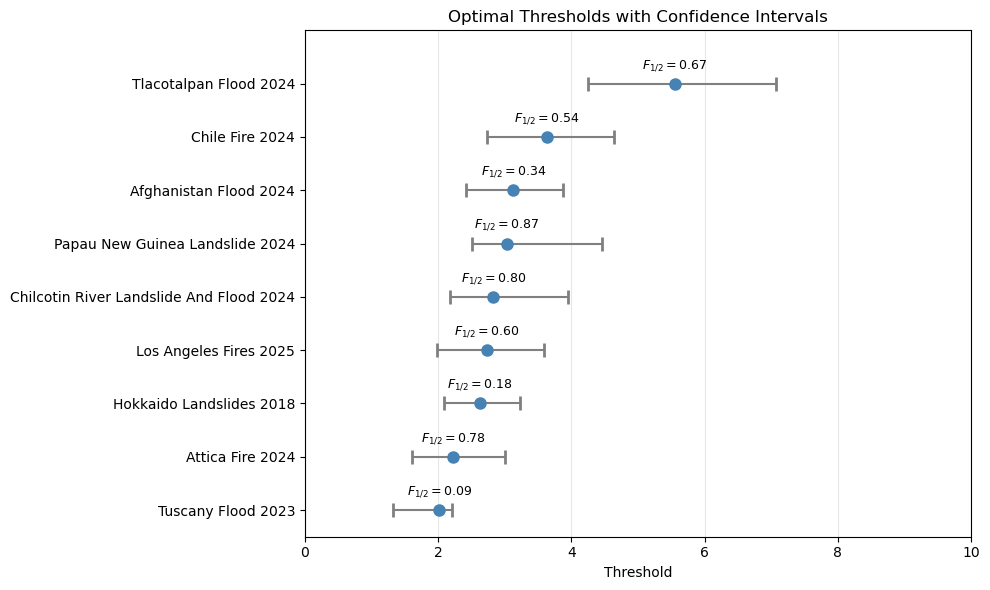

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by best_threshold for better visualization
df_sorted = df.sort_values('best_threshold').reset_index(drop=True)

# Calculate error bar distances (asymmetric)
xerr_left = df_sorted['best_threshold'] - df_sorted['left_threshold']
xerr_right = df_sorted['right_threshold'] - df_sorted['best_threshold']

# Plot optimal thresholds as dots with error bars
ax.errorbar(
    x=df_sorted['best_threshold'],
    y=range(len(df_sorted)),
    xerr=[xerr_left, xerr_right],
    fmt='o',
    capsize=5,
    capthick=2,
    markersize=8,
    color='steelblue',
    ecolor='gray',
    label='Optimal Threshold'
)

# Add F-score annotation above each point
for i, row in df_sorted.iterrows():
    ax.annotate("$F_{1/2}=$" + f"{row['best_fhalf']:.2f}", 
                xy=(row['best_threshold'], i),
                xytext=(0, 8), textcoords='offset points',
                fontsize=9, ha='center', va='bottom')

ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['event_name'].str.replace('_', ' ').str.title())
ax.set_xlabel('Threshold')
ax.set_title('Optimal Thresholds with Confidence Intervals')
ax.grid(axis='x', alpha=0.3)

ax.set_xlim(0, 10)
ax.set_ylim(-0.5, len(df_sorted) - 0.5 + 0.5)

plt.tight_layout()
plt.show()

In [27]:
low_alert = df.left_threshold
high_alert = df.right_threshold

weight = df.best_fhalf

low_alert_wm = np.sum(low_alert * weight) / np.sum(weight)
high_alert_wm = np.sum(high_alert * weight) / np.sum(weight)


In [28]:
low_alert_wm, high_alert_wm

(np.float64(2.466139176199405), np.float64(4.283759374173339))